# Convolutional Neural Networks (CNNs)

### Welcome to the 5th Lab of 42028: Deep Learning and CNN!

In this  Lab/Tutorial session you will be implementing Convolutional Neural Network for Fashion MNIST dataset classification .

So lets get started!

## Tutorial:
Implementation of a sample CNN architecture using Keras for classfication of Fashion MNIST dataset.

## Tasks for this week:

1. Implementation of a CNN for Dogs and Cats classification using Keras API.
2. Train and test model


### Step 1: Import required packages

we will need tensorflow, numpy, os and keras


In [1]:
!pip install opencv-python-headless

In [2]:
import tensorflow as tf
import os
import numpy as np
import math, numpy as np
import sklearn.datasets
import matplotlib.pyplot as plt
import h5py
import glob
import cv2
import keras.utils as image
from tensorflow import keras

2026-03-16 02:37:56.308480: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Step 2: Download the Fashion Mnist dataset using keras

In [3]:
fashionMnist=tf.keras.datasets.fashion_mnist

In [4]:
# Load data from fashion mnist dataset using the load_data() method.
(train_images, train_labels), (test_images, test_labels) = fashionMnist.load_data()

In [5]:
# Display the shapes of the training images
print(train_images.shape)
print(train_images.dtype)

(60000, 28, 28)
uint8


In [6]:
#define the class names for the fashion mnist dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

3


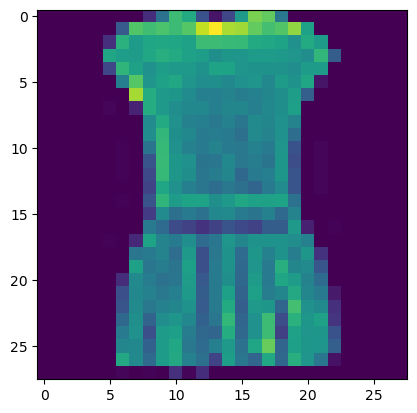

In [7]:
## Display an image from the dataset
import matplotlib.pyplot as plt
plt.imshow(train_images[3])
print(train_labels[3])

**Note :** Scikit-learn import the Fashion MNIST dataset as a 1-D array while Keras API load the dataset in 28X28 format.

### Step 3: Normalize the dataset and split a small part of the training set into validation set


- Validation set: first 5000 samples (total 5000 samples)
- Training set: 5000 to remaining (total 55000 samples)

In [8]:
## WRITE YOUR CODE HERE ## (~ 5 line of code)
## Hint: Using slicing to split the training to train and validation

train_images=train_images.reshape(60000, 28, 28, 1)
valid_images= train_images[:5000] / 255.0
valid_labels = train_labels[:5000]

train_images  = train_images[5000:] / 255.0
train_labels=train_labels[5000:]

test_images = test_images.reshape(10000, 28, 28, 1)
test_images = test_images / 255.0

### END YOUR CODE HERE ###

In [9]:
# Print the shapes for Train, Validation, and Test dataset.
print(np.shape(train_images))
print(np.shape(valid_images))
print(np.shape(test_images))

(55000, 28, 28, 1)
(5000, 28, 28, 1)
(10000, 28, 28, 1)


[**Expected** Output]

(55000, 28, 28)
(5000, 28, 28)
(10000, 28, 28)

### Step 4:  Design the CNN Architecture

Design the following CNN architecture (See image below):


Input: $64 X 64 X 3$ image

Activation function in CONV layer: Relu

Activation function in Output layer : softmax, 10 classes

**Hint:** Use Conv2D(), MaxPooling2D(), Flatten(), and Dense()



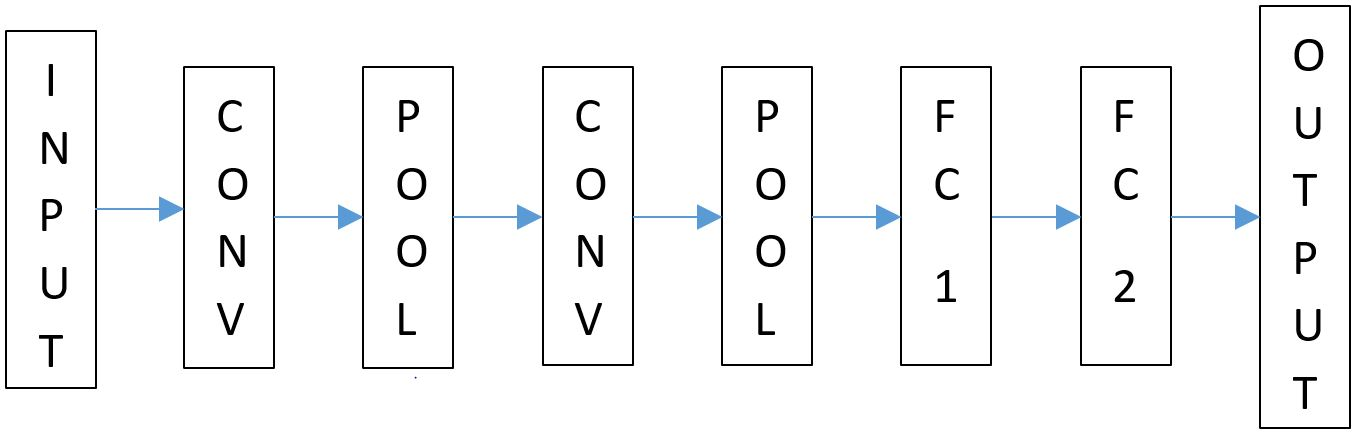

In [10]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(28, 28, 1)),
  tf.keras.layers.MaxPooling2D(2, 2),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])

/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## **Notes:**
* **Sequential model.** This is the simplest kind of Keras model, for neural networks which defines a SEQUENCE of layers.

* **Flatten.** Flatten just takes that image and turns it into a 1-dimensional vector.

* Next we add a second Dense hidden layer with 128 neurons, also using the ReLU activation function.  **Dense.** Add a layer to the neural network which is followed by activation function of ReLU. The ReLU only passes the value greater than 0 and for all other values of X it passes 0.
e.g. If X>0 return X, else return 0"

* Finally, we add a Dense output layer with 10 neurons (one per class), using the softmax activation function.

* ** Softmax** The softmax takes a set of values and select the biggest one from the set of values.

## Step 5: Training the model

**"sparse_categorical_crossentropy": **   The dataset contains sparse labels and the classes are exclusive.

** One-hot vector encoding** This is sometime used for encoding the labels if there one target  probability per class for each instance. For example.
[0., 0., 0., 0., 1., 0., 0., 0., 0., 0.] represent one-hot encoding for class 4. In such case, **"categorical_crossentropy"** loss is used.

** "sigmoid_crossentropy"** This loss is used for binary class classification problems and also **"sigmoid"** activation function is used instead of Softmax.



In [11]:
# Intsall pydot library
!pip install pydot

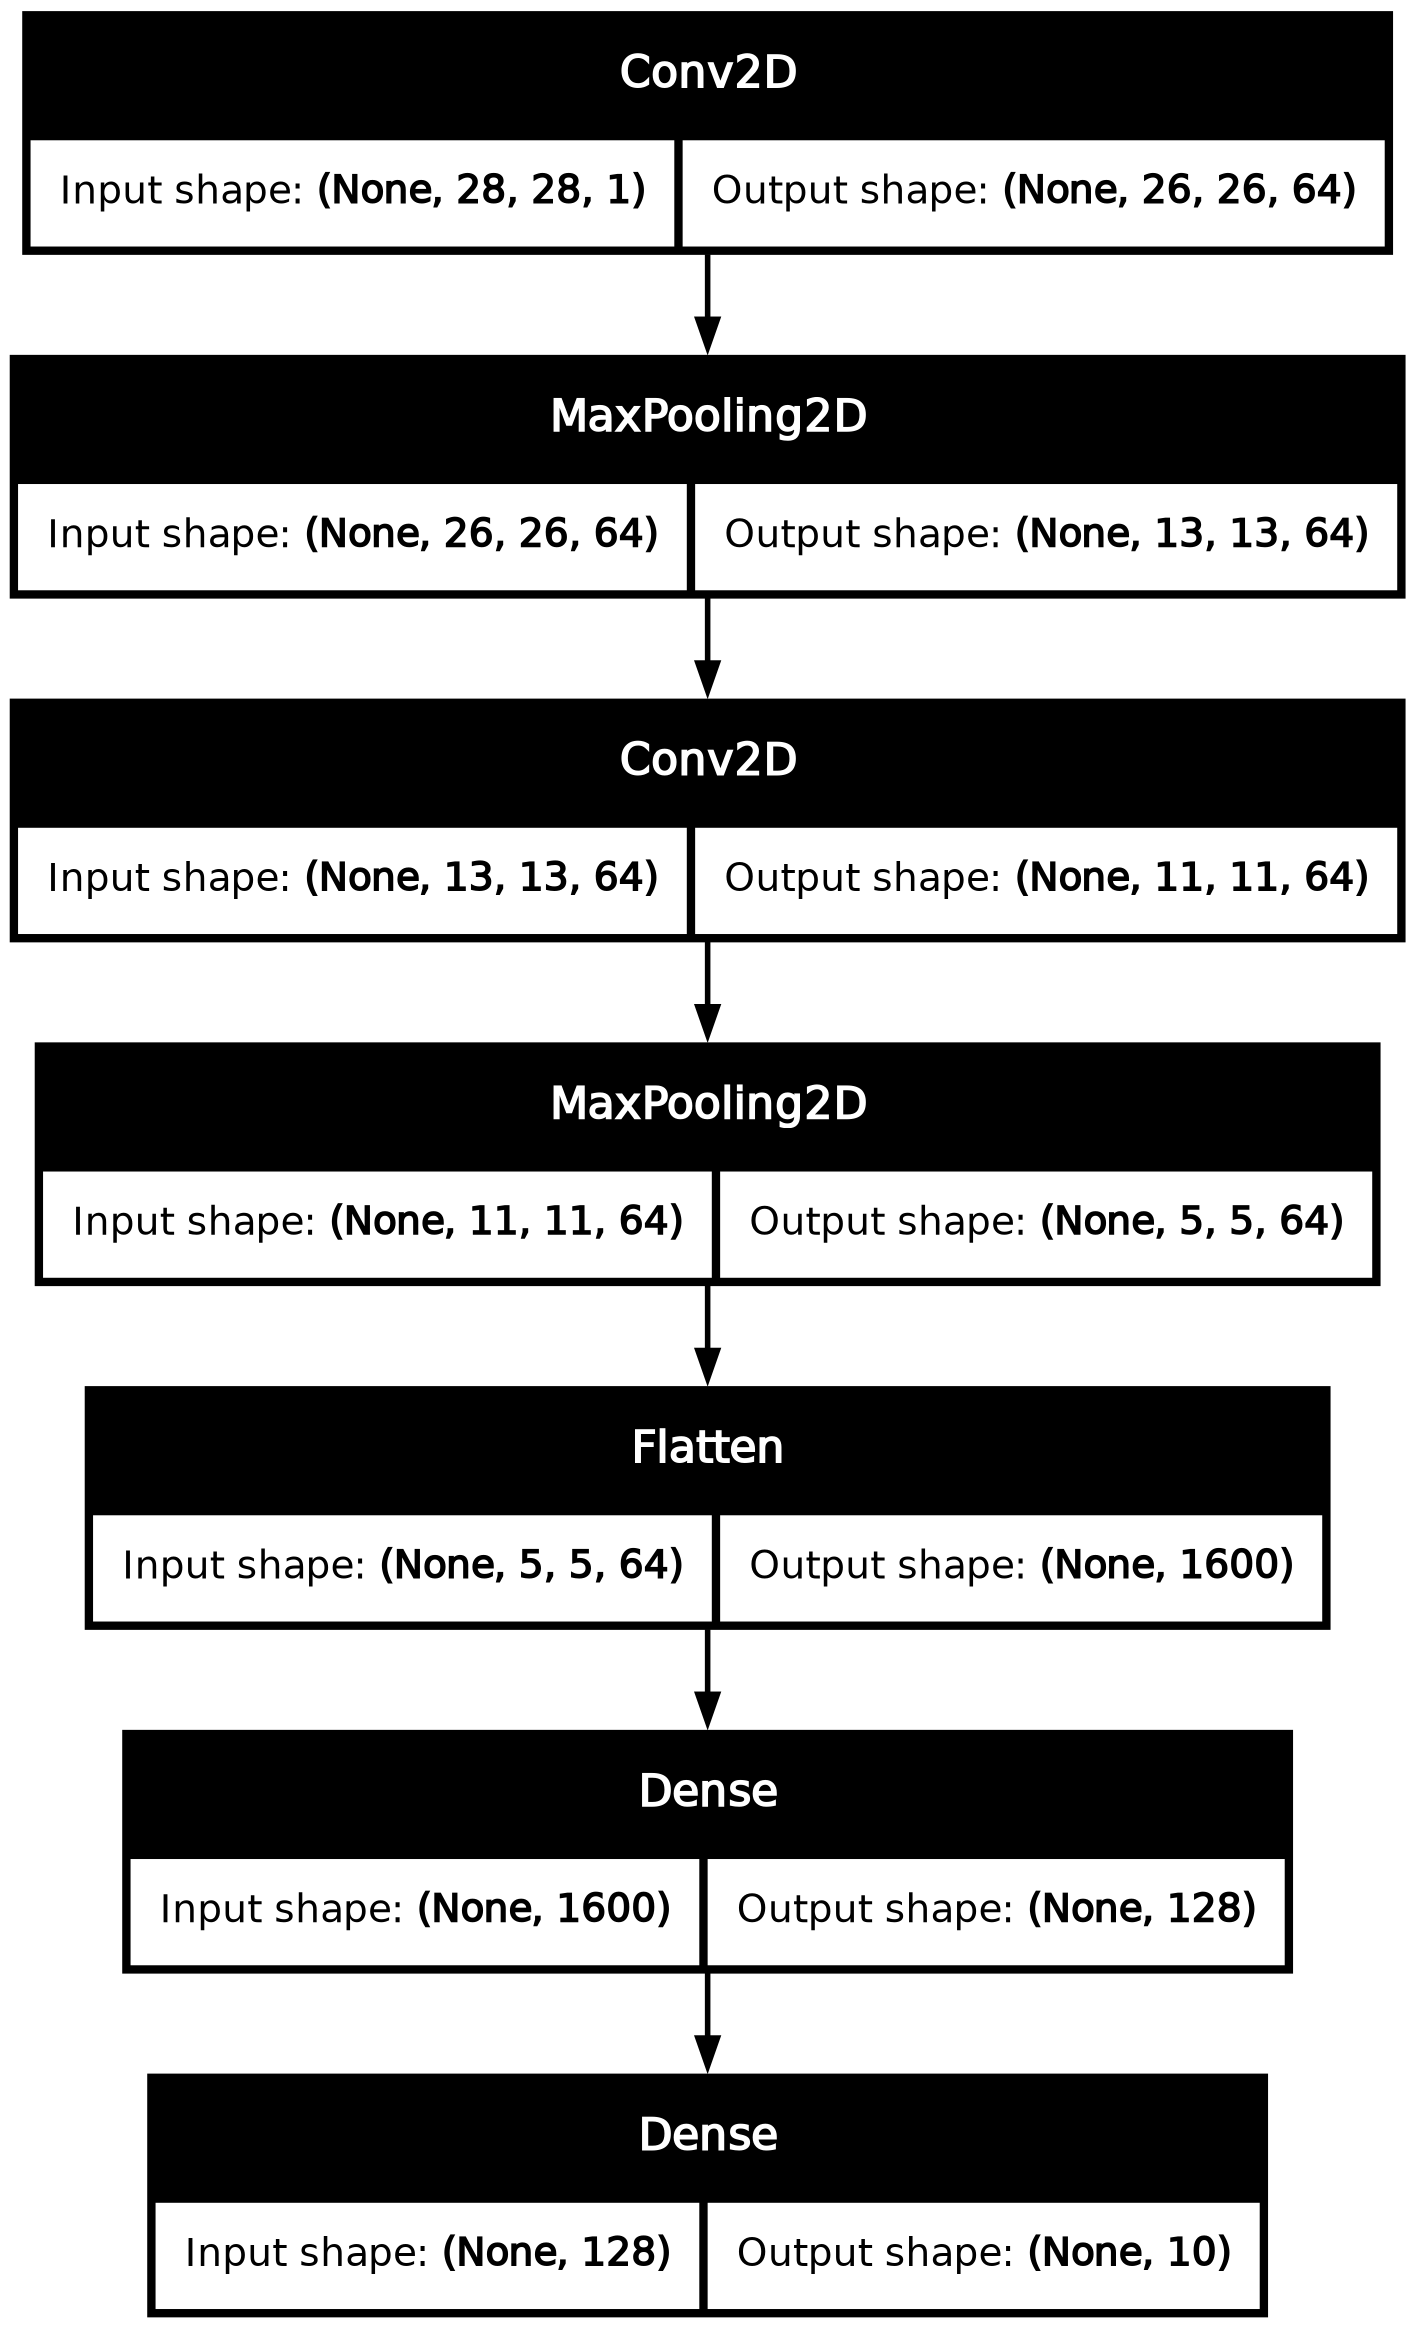

In [12]:
# Visualize Network Model

import pydot

# Using Plot_Model from Keras.Utils
model_img_file = 'CNN-model1.png'
tf.keras.utils.plot_model(model, to_file=model_img_file,
                          show_shapes=True,
                          show_layer_activations=False,
                          show_dtype=False,
                          show_layer_names=False)

# Also Try:
# show_shapes=True, show_layer_activations=True, show_dtype=True, show_layer_names=True

In [13]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()
model.fit(train_images, train_labels, epochs=5)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,786 (952.29 KB)

 Trainable params: 243,786 (952.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


2026-03-16 02:38:07.987890: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 172480000 exceeds 10% of free system memory.


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 68s 38ms/step - accuracy: 0.8399 - loss: 0.4436
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - accuracy: 0.8908 - loss: 0.2994
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 64s 37ms/step - accuracy: 0.9073 - loss: 0.2530
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 87s 40ms/step - accuracy: 0.9173 - loss: 0.2211
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 66s 38ms/step - accuracy: 0.9280 - loss: 0.1932


In [14]:
# Process the test images and find the accuracy
test_loss = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9025 - loss: 0.2744


### Summary of the model

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 731,360 (2.79 MB)

 Trainable params: 243,786 (952.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 487,574 (1.86 MB)

## Step 6: Evaluation on test dataset

In [16]:
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9025 - loss: 0.2744


[0.2743886113166809, 0.9024999737739563]

## Task: Image classification using Cats and Dogs Dataset.

###  Step: 1 Upload and unzip the Cats and Dogs Dataset
Reference: https://github.com/ardamavi/Dog-Cat-Classifier



In [17]:
!unzip Cats-Dogs-dataset-64.zip
!ls

Archive:  Cats-Dogs-dataset-64.zip
replace TestData/cat/cat.282.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C
 CNN-model1.png
 CNN-model2.png
 Cats-Dogs-dataset-64.zip
 TestData
 TrainData
'Week5-ConvolutionalNeuralNetworks(CNNs)-Solution.ipynb'
'Week5-ConvolutionalNeuralNetworks(CNNs).ipynb'


### Step : 2 Image Generators: (Preparing the dataset for train, validation and testing)

In Keras  **keras.preprocessing.image.ImageDataGenerator** class  can be used to read images and extract labels from them via .flow_from_directory. The image generator can also be used for data augmentation. The image generators can used easily with Keras model that accept data generators as inputs. such as fit_generator, evaluate_generator, and predict_generator.


In [18]:
!pwd

/home/sagemaker-user/42028/Week5


In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# All images will be rescaled by 1./255
train_datagen = ImageDataGenerator(rescale=1/255)
validation_datagen = ImageDataGenerator(rescale=1/255)


# Flow training images in batches of 32 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        './TrainData',  # This is the source directory for training images (Current Directory)
        target_size=(64, 64),  # All images will be resized to 64X64
        batch_size=30,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

# Flow training images in batches of 32 using train_datagen generator
validation_generator = validation_datagen.flow_from_directory(
        './TrainData',  # This is the source directory for training images (Current Directory)
        target_size=(64, 64),  # All images will be resized to 64X64
        batch_size=30,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [20]:
print(train_generator.class_indices)   # should show {'cat': 0, 'dog': 1}
print(train_generator.samples) 

{'cat': 0, 'dog': 1}
500


### Step 3: Create the CNN model:

Create the following CNN model (See image below):


Input: $64 X 64 X 3$ image

Activation function in CONV layer: Relu

Activation function in Output layer : sigmoid, 2 classes

**Hint:** Use Conv2D(), MaxPooling2D(), Flatten(), and Dense()

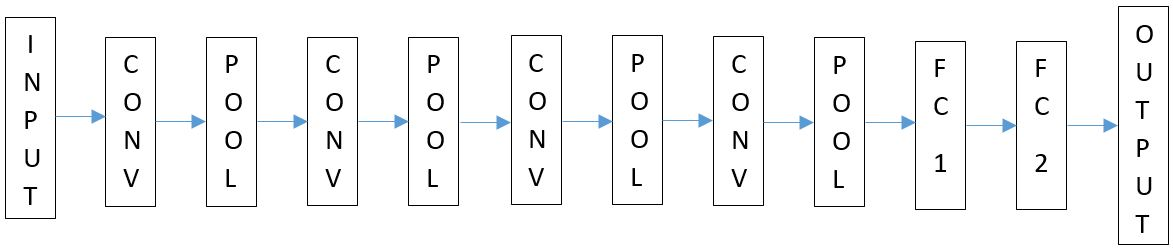

In [21]:
model1 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(64, 64, 3)),
    # This is the first convolution
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    # The second convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The third convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The fourth convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    # Only 1 output neuron. It will contain a value from 0-1 where 0 for 1 class ('horses') and 1 for the other ('humans')
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [22]:
##Print the model summary
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 192,609 (752.38 KB)

 Trainable params: 192,609 (752.38 KB)

 Non-trainable params: 0 (0.00 B)

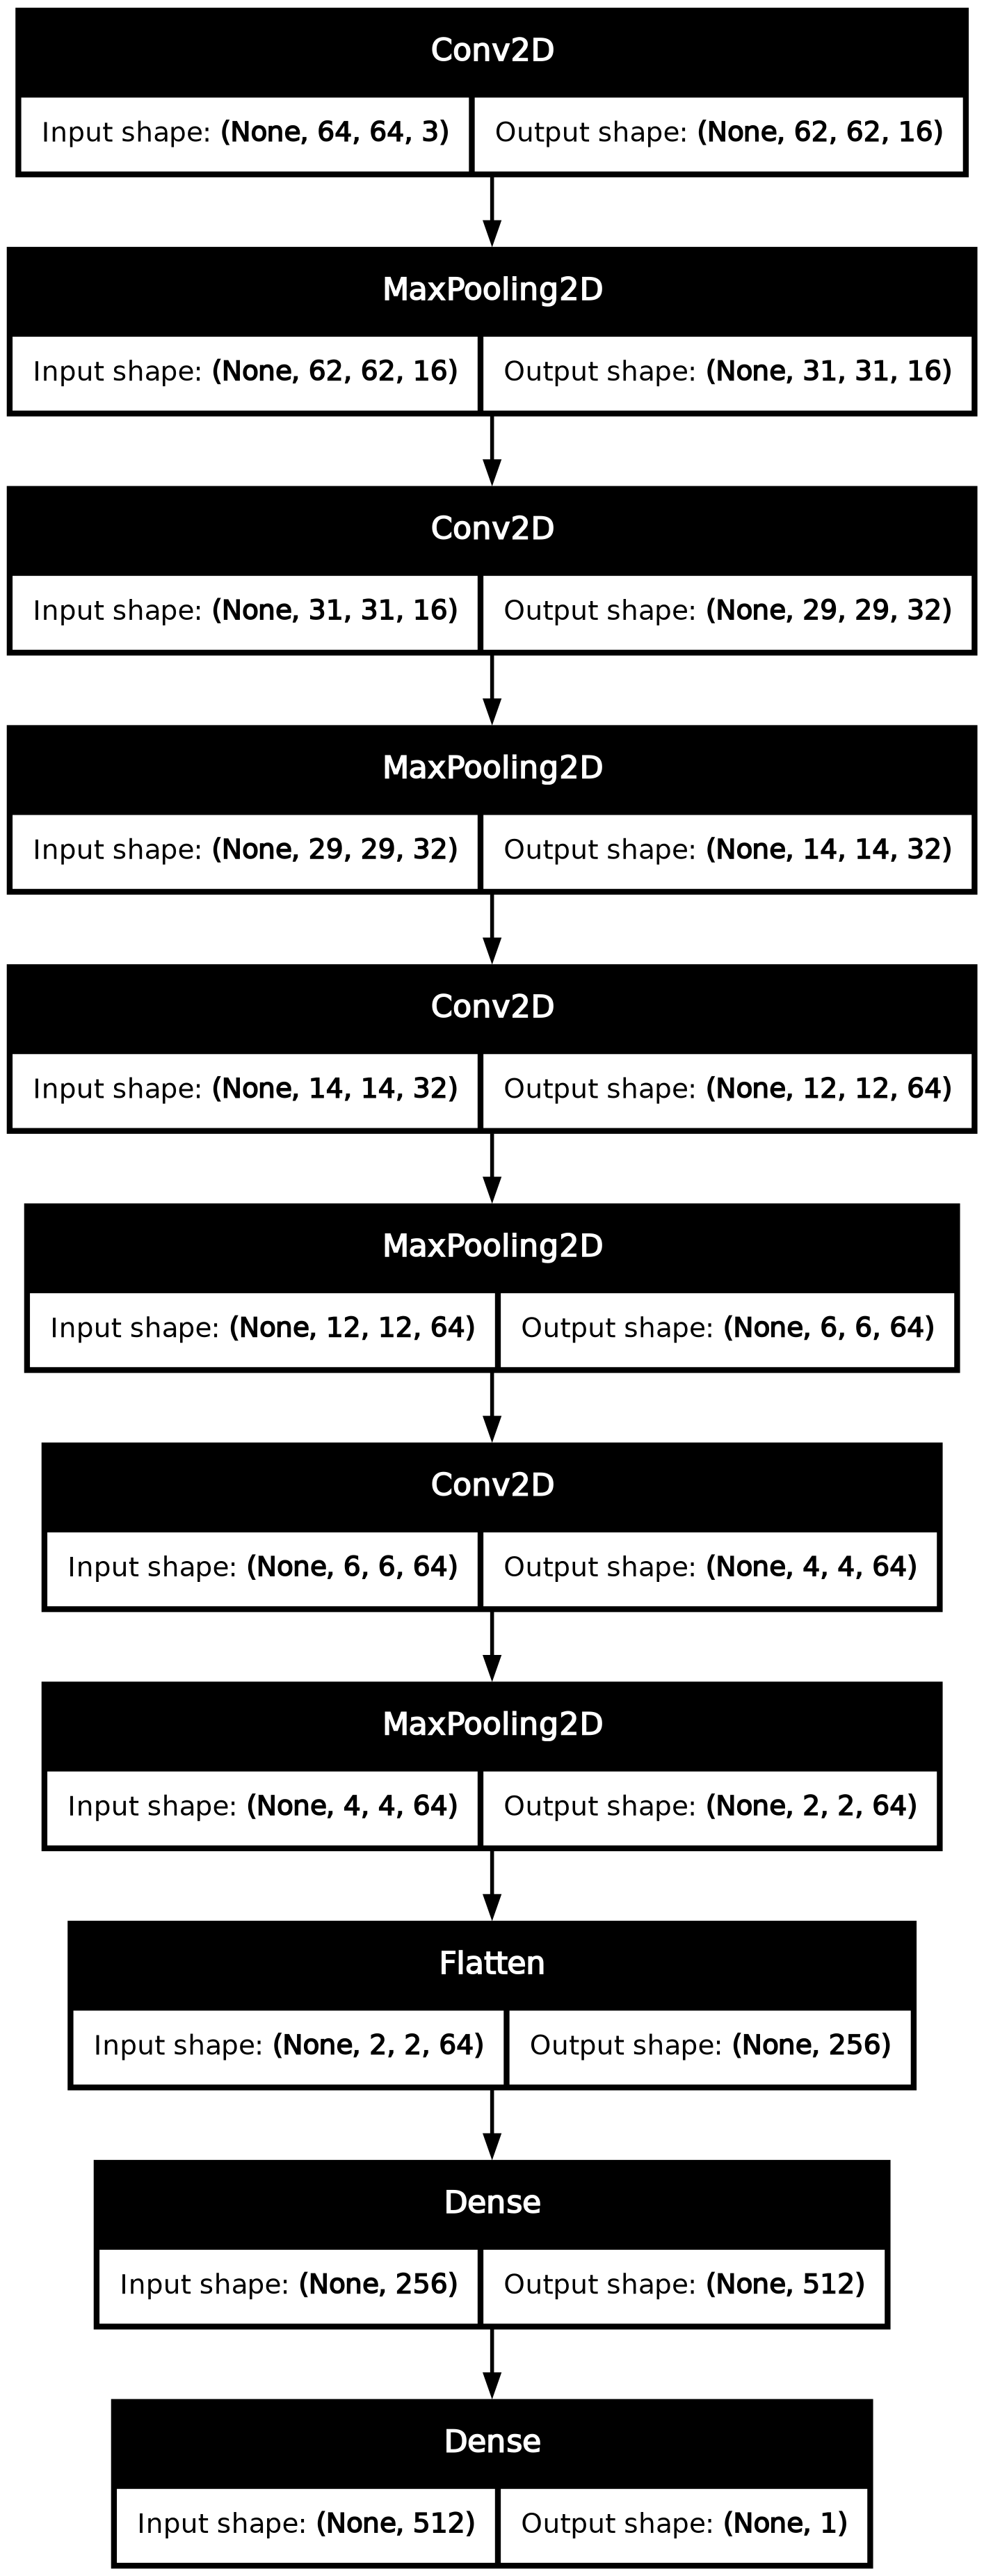

In [23]:
# Using Plot_Model from Keras.Utils
model_img_file = 'CNN-model2.png'
tf.keras.utils.plot_model(model1, to_file=model_img_file,
                          show_shapes=True,
                          show_layer_activations=False,
                          show_dtype=False,
                          show_layer_names=False )

# Also Try:
# show_shapes=True, show_layer_activations=True, show_dtype=True, show_layer_names=True

In [24]:
## Compile the model and add loss, optimizer and metrics
## WRITE YOUR CODE HERE ## (~1 line)
model1.compile(loss='binary_crossentropy',
              optimizer=tf.optimizers.Adam(),
              metrics=['acc'])

In [25]:
# Train/fit the model using the training and validation set.
## WRITE YOUR CODE HERE ## (~ 1 line)
history = model1.fit(
      train_generator,
      steps_per_epoch=20,
      epochs=30,
      verbose=1,
      validation_data = validation_generator,
      validation_steps=20)

Epoch 1/30
17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - acc: 0.5066 - loss: 0.6955

/opt/conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - acc: 0.5120 - loss: 0.6949 - val_acc: 0.5000 - val_loss: 0.6935
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - acc: 0.4540 - loss: 0.6974 - val_acc: 0.6240 - val_loss: 0.6920
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - acc: 0.5280 - loss: 0.6940 - val_acc: 0.5580 - val_loss: 0.6912
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - acc: 0.4980 - loss: 0.6929 - val_acc: 0.5940 - val_loss: 0.6902
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - acc: 0.5920 - loss: 0.6836 - val_acc: 0.5340 - val_loss: 0.6772
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - acc: 0.5820 - loss: 0.6783 - val_acc: 0.6060 - val_loss: 0.6541
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - acc: 0.6080 - loss: 0.6536 - val_acc: 0.6620 - val_loss: 0.6317
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - acc: 0.6520 - loss: 0.6230 - val_acc: 0.6520 - val_loss: 0.6135
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - acc: 0.6880 -

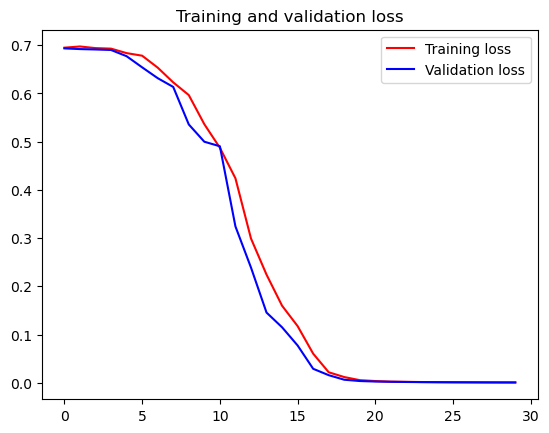

In [26]:
## Plot the Training and Validation loss
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(loss))

plt.figure()

plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

